# I. Разминка numpy (1 балл)

## 1. Парсеки

Напишите функцию, которая принимает на вход:
- np.array - набор расстояний от Земли до звёзд (в световых годах)
- k - количество значений, которое нам нужно

Выведите топ-k самых удаленных звёзд от нас в порядке убывания разрастания, расстояния выведите в парсеках (1 парсек приблизительно равен 3.262 световым годам)

In [ ]:
def find_top_k_longest_distance_stars(star_distances, k): # TODO
  sorted_distances = np.sort(star_distances)[::-1]
  sorted_distances = sorted_distances[0:k] / 3.262
  return sorted_distances


In [ ]:
# Просто пример, можно придумать свой
import numpy as np
print(find_top_k_longest_distance_stars(np.array([4.37, 8.6, 4.24, 4.37, 5.96, 7.8, 8.6, 7.9]), 4))

[2.63641937 2.63641937 2.4218271  2.39117106]


## 2. Оцениваем размер галактики

Напишите функцию, которая принимает на вход:
- np.array - набор масс звёзд в галактике
- k - количество максимальных по массе звёзд

Функция должна вывести два числа - первое - сумму масс первых k звёзд по массе, второе - сумму масс остальных звёзд.

In [ ]:
def count_k_masses(masses, k): # TODO
  sorted_masses = np.sort(masses)[::-1]
  big_stars = 0
  for i in range(k):
    big_stars += sorted_masses[i]
  left_stars = np.sum(sorted_masses) - big_stars
  return big_stars, left_stars

In [ ]:
# Просто пример, можно придумать свой
import numpy as np
print(count_k_masses(np.array([150, 200, 300, 250, 400, 100, 200]), 2))

(700, 900)


# II. Помогаем Карелии

## 0. Загрузи датасет в этот блокнот (0.5 балла)

Открой гугл-диск курса, разархивируй zip-архив и собери нужные наборы данных из архива в единый датасет при помощи pandas.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

In [ ]:


#датафрейм по доходам
dataframes_income = []
for i in range(2010, 2021):
    if i<2012 or i>2015:
      if i>2015:
        df = pd.read_excel(f'/content/drive/MyDrive/Colab Notebooks/{str(i)}'+'.xlsx', sheet_name='доходы (исполнено), ' + str(i))
        df.drop([0], inplace=True)
      else:
        df = pd.read_excel(f'/content/drive/MyDrive/Colab Notebooks/{str(i)}'+'.xlsx', sheet_name='доходы (исполнено) ' + str(i))
        df.drop([0, 1], inplace=True)
      df.columns = ['Наименование показателя', '2', '3', f'{i}']
      df_1 = df.drop(columns=['2', '3'])
      df_1.replace(to_replace=r'(?i).*(итого|всего).*', value='Доходы итого', regex=True, inplace=True)
      dataframes_income.append(df_1)

    else:
      if i == 2012 or i == 2014:
        df = pd.read_excel(f'/content/drive/MyDrive/Colab Notebooks/{str(i)}'+'.XLS', sheet_name='доходы (исполнено) ' + str(i))
      else:
        df = pd.read_excel(f'/content/drive/MyDrive/Colab Notebooks/{str(i)}'+'.xls', sheet_name='доходы (исполнено) ' + str(i))
      if i == 2012:
        df.columns = ['Наименование показателя', '2', '3', '4', f'{i}']
        df_1 = df.drop(columns=['2', '3', '4'])
      else:
        df.columns = ['Наименование показателя', '2', '3', f'{i}']
        df_1 = df.drop(columns=['2', '3'])
      df_1.drop([0, 2], inplace=True)
      df_1.replace(to_replace=r'(?i).*(итого|всего).*', value='Доходы итого', regex=True, inplace=True)
      dataframes_income.append(df_1)

dataframes_income[8].head(15)



<ipython-input-63-1accfe1fe7da>:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1.replace(to_replace=r'(?i).*(итого|всего).*', value='Доходы итого', regex=True, inplace=True)
<ipython-input-63-1accfe1fe7da>:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1.replace(to_replace=r'(?i).*(итого|всего).*', value='Доходы итого', regex=True, inplace=True)
<ipython-input-63-1accfe1fe7da>:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicit

,Наименование показателя,2018
1,Доходы итого,4.726860e+10
2,НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ,2.660435e+10
3,"НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ",1.690036e+10
4,Налог на прибыль организаций,8.128882e+09
5,"Налог на прибыль организаций, зачисляемый в бю...",8.128882e+09
6,Налог на прибыль организаций (за исключением к...,5.535557e+09
7,Налог на прибыль организаций консолидированных...,2.593326e+09
8,Налог на доходы физических лиц,8.771476e+09
9,"Налог на доходы физических лиц с доходов, исто...",8.523941e+09
10,"Налог на доходы физических лиц с доходов, полу...",5.137654e+07


In [ ]:
#датафрейм по расходам
dataframes_expense = []
for i in range(2010, 2021):
  if i==2012 or i == 2014:
    file_path = f'/content/drive/MyDrive/Colab Notebooks/{i}.XLS'
  elif i == 2013 or i == 2015:
    file_path = f'/content/drive/MyDrive/Colab Notebooks/{i}.xls'
  else:
    file_path = f'/content/drive/MyDrive/Colab Notebooks/{i}.xlsx'
  xls = pd.ExcelFile(file_path)
  sheet_names = xls.sheet_names
  expenses_sheets = [sheet for sheet in sheet_names if 'расходы' in sheet.lower()]
  if len(expenses_sheets) == 1:
    df = pd.read_excel(file_path, sheet_name=expenses_sheets[0])
    df.replace(to_replace=r'(?i).*(итого|всего).*', value='Расходы итого', regex=True, inplace=True)
    if i<=2015:
      df = df.iloc[:, [0, -1]]
    else:
      df = df.iloc[:, [1, -1]]
    df.columns = ['Наименование показателя', f'{i}']
    dataframes_expense.append(df)

dataframes_expense[7].tail(10)


,Наименование показателя,2017
1185,Дотации,1.000000e+08
1186,Иные дотации,1.000000e+08
1187,Прочие межбюджетные трансферты общего характера,4.347391e+08
1188,Межбюджетные трансферты,4.347391e+08
1189,Субсидии,4.069491e+08
1190,"Субсидии, за исключением субсидий на софинанси...",4.069491e+08
1191,Субвенции,2.779000e+07
1192,NaN,NaN
1193,NaN,NaN
1194,NaN,NaN


## 1. Предобработка датасета (2 балла)

- изучи датасет
- очисти данные в нём (есть ли в нём пропуски и выбросы? что ты можешь с ними сделать? сделай это.)

In [ ]:
df_inc = dataframes_income[0]
for i in range(1, 11):
    df_inc = pd.merge(df_inc, dataframes_income[i], on='Наименование показателя', how='inner')
    df_inc = df_inc.drop_duplicates(subset=['Наименование показателя'], keep='first')
    df_inc = df_inc.dropna()
df_inc.reset_index(drop=True, inplace=True)

,Наименование показателя,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Доходы итого,2.487344e+10,2.755647e+10,2.689315e+10,2.398424e+10,2.775021e+10,2.839088e+10,3.254645e+10,3.438536e+10,4.726860e+10,5.127276e+10,6.059738e+10
1,НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ,1.532213e+10,1.820269e+10,1.757042e+10,1.517376e+10,1.595676e+10,1.780816e+10,1.965441e+10,2.012920e+10,2.660435e+10,2.776398e+10,2.713114e+10
2,"НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ",8.613483e+09,1.133454e+10,1.081373e+10,8.101886e+09,8.916328e+09,9.962889e+09,1.151807e+10,1.170081e+10,1.690036e+10,1.733688e+10,1.516577e+10
3,Налог на прибыль организаций,3.980212e+09,6.262562e+09,5.279888e+09,2.200022e+09,1.837840e+09,3.114014e+09,4.280042e+09,4.022683e+09,8.128882e+09,8.162340e+09,5.058408e+09
4,"Налог на прибыль организаций, зачисляемый в бю...",3.980212e+09,6.262562e+09,5.279888e+09,2.200022e+09,1.837840e+09,3.114014e+09,4.280042e+09,4.022683e+09,8.128882e+09,8.162340e+09,5.058408e+09
5,Налог на доходы физических лиц,4.633271e+09,5.071977e+09,5.533845e+09,5.901864e+09,7.078488e+09,6.848875e+09,7.238029e+09,7.678124e+09,8.771476e+09,9.174541e+09,1.010736e+10
6,"НАЛОГИ НА ТОВАРЫ (РАБОТЫ, УСЛУГИ), РЕАЛИЗУЕМЫЕ...",2.022770e+09,2.137298e+09,2.522932e+09,2.339682e+09,2.101871e+09,2.286123e+09,2.647462e+09,2.280842e+09,2.411248e+09,2.987134e+09,4.451614e+09
7,"Акцизы по подакцизным товарам (продукции), про...",2.022770e+09,2.137298e+09,2.522932e+09,2.339682e+09,2.101871e+09,2.286123e+09,2.647462e+09,2.280842e+09,2.411248e+09,2.987134e+09,4.451614e+09


In [ ]:
df_exp = dataframes_expense[0]
for i in range(1, 11):
  df_exp = pd.merge(df_exp, dataframes_expense[i], on='Наименование показателя', how='inner')
  df_exp = df_exp.drop_duplicates(subset=['Наименование показателя'], keep='first')
  df_exp = df_exp.dropna()
df_exp.reset_index(drop=True, inplace=True)
#df_exp.tail(8)

,Наименование показателя,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
30,Амбулаторная помощь,3.123525e+07,6.827384e+08,781069500.7,273040221.32,2.503561e+08,3.408167e+08,3.100912e+08,2.259427e+08,607095838.48,5.881962e+08,807447805.52
31,Медицинская помощь в дневных стационарах всех ...,3.639863e+07,3.722818e+07,36942234.84,50493364.97,5.311873e+07,3.339730e+07,3.485480e+07,3.605800e+07,49371700,5.126360e+07,52560700
32,Скорая медицинская помощь,1.594648e+07,2.481903e+07,389788286.33,77558000,7.433290e+07,4.960830e+07,9.024366e+07,9.314356e+07,107103000,2.269098e+08,236384900
33,Пенсионное обеспечение,9.268151e+07,1.115253e+08,121323822.68,132832320.3,1.441400e+08,1.476857e+08,1.599490e+08,1.845540e+08,211599339.74,1.865767e+08,923374205.75
34,Социальное обслуживание населения,5.379140e+08,1.296291e+09,1040601923.09,1202304654.57,1.233887e+09,1.180445e+09,1.094221e+09,1.168187e+09,1583911690.89,1.823256e+09,2166672683.06
35,Социальное обеспечение населения,5.556901e+09,5.510346e+09,5459395243.98,5304087769.94,5.233812e+09,5.513860e+09,5.944818e+09,1.032297e+10,10972082786.42,1.068044e+10,13664269548.32
36,Охрана семьи и детства,4.216267e+06,1.745658e+08,705944465.82,639147025.81,7.129939e+08,6.819497e+08,9.661171e+08,1.016595e+09,1065327358.71,1.122218e+09,1163137105.13
37,Другие вопросы в области социальной политики,8.858598e+06,8.229087e+06,9174500,11495826,1.290500e+07,1.175532e+07,2.063997e+07,9.583790e+07,83515311.65,1.365834e+08,128533901.68


## 2. Найди параметры, которые влияют на бюджет (3.5 балла)

Поэкспериментируй с параметрами, найди 3 параметра, которые сильно связаны с значением бюджета Карелии за год (тут есть две цифры - расходы бюджета ИТОГО и доходы бюджета ИТОГО - искать параметры надо к обоим на основе **предыдущего года**) (при помощи коэффициента корреляции). Настоятельно рекомендуем поиграть с разными параметрами  - попробовать линейные комбинации, некоторые функции от параметров (log, возведение в степень, etc).

Оставь весь код экспериментов в этом блоке, но в конце опиши, какие параметры в итоге ты берёшь.

In [ ]:
top_articles_of_budget=[]
df_inc_corr = df_inc
for i in range(1, 69):
  if sum(df_inc_corr.iloc[i, 1:11])/sum(df_inc_corr.iloc[0, 2:12]) >= 0.05:
     top_articles_of_budget.append(df_inc_corr.iat[i, 0])
df_inc_corr["Корреляция с доходами"] = 0
df_inc_corr["Корреляция с расходами"] = 0

top_articles_of_budget_e=[]
df_exp_corr = df_exp
for i in range(1, 37):
  if sum(df_exp_corr.iloc[i, 1:11])/sum(df_exp_corr.iloc[0, 2:12]) >= 0.05:
     top_articles_of_budget_e.append(df_exp_corr.iat[i, 0])
df_exp_corr["Корреляция с расходами"] = 0
df_exp_corr["Корреляция с доходами"] = 0

overall_expense_ne=df_exp_corr.iloc[0, 2:12]
overall_income_ne=df_inc_corr.iloc[0, 2:12]

for i in range(1, 69):
  #корреляция статьи доходов с общими доходами
  df_inc_corr.iat[i, 12] = df_inc_corr.iloc[i, 1:11].corr(overall_income_ne)
  if df_inc_corr.iat[i, 12] >= 0.90 and df_inc_corr.iat[i, 0] in top_articles_of_budget:
    print(i, f'Высокая корреляция {df_inc_corr.iat[i, 0]} с доходами Карелии: {df_inc_corr.iat[i, 12]}, доля которых:', sum(df_inc_corr.iloc[i, 1:11])/sum(df_inc_corr.iloc[0, 2:12]))
  #Корреляция статьи доходов с общими расходами
  df_inc_corr.iat[i, 13] = df_inc_corr.iloc[i, 1:11].corr(overall_expense_ne)
  if df_inc_corr.iat[i, 13] >= 0.90:
    print(i, f'Высокая корреляция {df_inc_corr.iat[i, 0]} с расходами Карелии: {df_inc_corr.iat[i, 13]}')

for i in range(1, 37):
  #корреляция статьи расходов с общими расходами
  df_exp_corr.iat[i, 12] = df_exp_corr.iloc[i, 1:11].corr(overall_expense_ne)
  if df_exp_corr.iat[i, 12] >= 0.90 and df_exp_corr.iat[i, 0] in top_articles_of_budget_e:
    print(i, f'Высокая корреляция {df_exp_corr.iat[i, 0]} с расходами Карелии: {df_exp_corr.iat[i, 12]}, доля которых:', sum(df_exp_corr.iloc[i, 1:11])/sum(df_exp_corr.iloc[0, 2:12]))
  #корреляция статьи расходов с общими доходами
  df_exp_corr.iat[i, 13] = df_exp_corr.iloc[i, 1:11].corr(overall_income_ne)
  if df_exp_corr.iat[i, 13] >+ 0.90:
    print(i, f'Высокая корреляция {df_exp_corr.iat[i, 0]} с доходами Карелии: {df_exp_corr.iat[i, 13]}')

for i in range(1, 69):
  #антикорреляция статьи доходов с общими доходами
  df_inc_corr.iat[i, 12] = df_inc_corr.iloc[i, 1:11].corr(overall_income_ne)
  if df_inc_corr.iat[i, 12] <= -0.75 and df_inc_corr.iat[i, 0] in top_articles_of_budget:
    print(i, f'Высокая корреляция {df_inc_corr.iat[i, 0]} с доходами Карелии: {df_inc_corr.iat[i, 12]}, доля которых:', sum(df_inc_corr.iloc[i, 1:11])/sum(df_inc_corr.iloc[0, 2:12]))
  #антикорреляция статьи доходов с общими расходами
  df_inc_corr.iat[i, 13] = df_inc_corr.iloc[i, 1:11].corr(overall_expense_ne)
  if df_inc_corr.iat[i, 13] <= -0.75:
    print(i, f'Высокая корреляция {df_inc_corr.iat[i, 0]} с расходами Карелии: {df_inc_corr.iat[i, 13]}')

for i in range(1, 37):
  #антикорреляция статьи расходов с общими расходами
  df_exp_corr.iat[i, 12] = df_exp_corr.iloc[i, 1:11].corr(overall_expense_ne)
  if df_exp_corr.iat[i, 12] <= -0.75 and df_exp_corr.iat[i, 0] in top_articles_of_budget_e:
    print(i, f'Высокая корреляция {df_exp_corr.iat[i, 0]} с расходами Карелии: {df_exp_corr.iat[i, 12]}, доля которых:', sum(df_exp_corr.iloc[i, 1:11])/sum(df_exp_corr.iloc[0, 2:12]))
  #антикорреляция статьи расходов с общими доходами
  df_exp_corr.iat[i, 13] = df_exp_corr.iloc[i, 1:11].corr(overall_income_ne)
  if df_exp_corr.iat[i, 13] <= -0.75:
    print(i, f'Высокая корреляция {df_exp_corr.iat[i, 0]} с доходами Карелии: {df_exp_corr.iat[i, 13]}')

<ipython-input-52-c3d0873c7aab>:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9880873846293198' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_inc_corr.iat[i, 12] = df_inc_corr.iloc[i, 1:11].corr(overall_income_ne)
<ipython-input-52-c3d0873c7aab>:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9445294016374025' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_inc_corr.iat[i, 13] = df_inc_corr.iloc[i, 1:11].corr(overall_expense_ne)
<ipython-input-52-c3d0873c7aab>:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9503526994715131' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_exp_corr.iat[i, 12] = df

1 Высокая корреляция НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ с доходами Карелии: 0.9880873846293198, доля которых: 0.5384397770331919
1 Высокая корреляция НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ с расходами Карелии: 0.9445294016374025
2 Высокая корреляция НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ с доходами Карелии: 0.9667776068512652, доля которых: 0.31942441993616566
2 Высокая корреляция НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ с расходами Карелии: 0.9023517878524514
5 Высокая корреляция Налог на доходы физических лиц с расходами Карелии: 0.9337462361039394
8 Высокая корреляция Акцизы на пиво, производимое на территории Российской Федерации с расходами Карелии: 0.9116592702773161
9 Высокая корреляция НАЛОГИ НА СОВОКУПНЫЙ ДОХОД с расходами Карелии: 0.9535252174006413
10 Высокая корреляция Налог, взимаемый в связи с применением упрощенной системы налогообложения с расходами Карелии: 0.9522094974116643
11 Высокая корреляция Налог, взимаемый с налогоплательщиков, выбравших в качестве объекта налогообложения доходы, уменьшенные на велич

Я выбрала следующие параметры:
Доходы:
1. Акцизы на пиво, производимое на территории Российской Федерации(сильно коррелируют с доходами Карелии: > 0.9) (8)
2. Налог на добычу полезных ископаемых(сильно коррелирует с расходами Карелии: > 0.9) (22)
3. БЕЗВОЗМЕЗДНЫЕ ПОСТУПЛЕНИЯ ОТ ДРУГИХ БЮДЖЕТОВ БЮДЖЕТНОЙ СИСТЕМЫ РОССИЙСКОЙ ФЕДЕРАЦИИ(сильно коррелирует с доходами Карелии: > 0.95) (65)


Расходы:
1. Другие вопросы в области образования(сильно коррелируют с доходами Карелии: > 0.9) (24)
2. Функционирование высшего должностного лица субъекта Российской Федерации и муниципального образования(сильно коррелируют с доходами Карелии: > 0.95) (1)
3. Общее образование(сильно отрицательно скоррелирована с доходами Карелии: -0.9196951055662657) (21)

(i) - номер в статьи в сводных таблицах расходов/доходов, выводился предыдущим блоком кода






# 3. Графики (1 балл)

Построй графики с выбранными параметрами и бюджетом Карелии. Что ты на них видишь?

In [ ]:
rows_1 = [1, 21, 24]
rows_2 = [8, 22, 66]

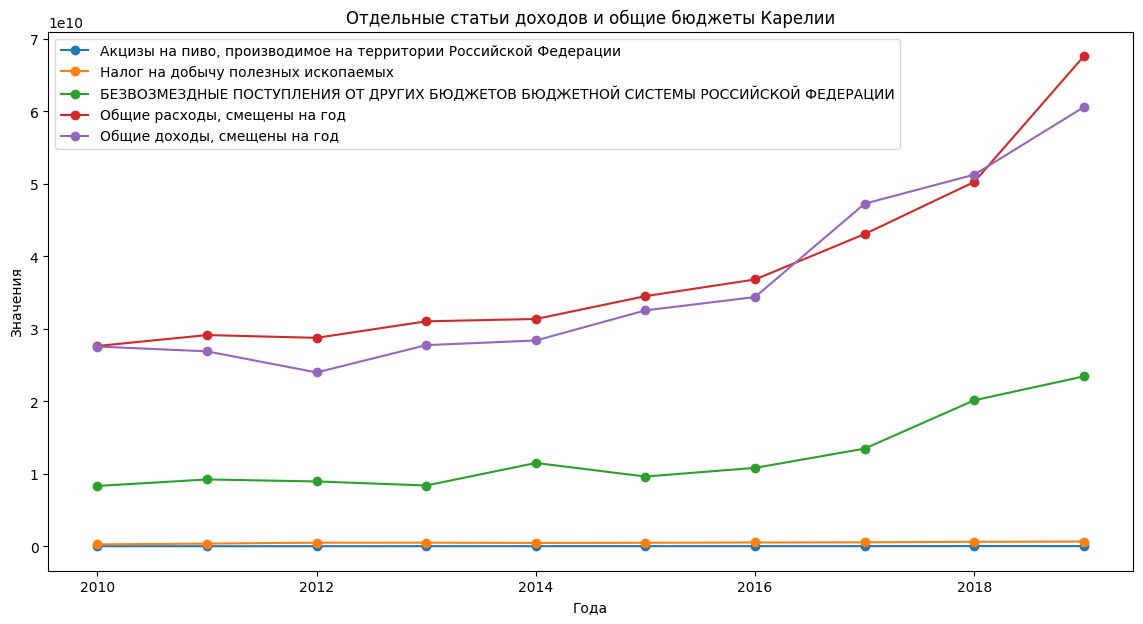

In [ ]:
import matplotlib.pyplot as plt

years = [i for i in range(2010, 2020)]
plt.figure(figsize=(14, 7))

for i in rows_2:
    plt.plot(years, df_inc.iloc[i, 1:11], marker='o', markersize=6, label=f'{df_inc.iloc[i, 0]}')

plt.plot(years, df_exp.iloc[0, 2:12], marker='o', markersize=6, label="Общие расходы, смещены на год")
plt.plot(years, df_inc.iloc[0, 2:12], marker='o', markersize=6, label="Общие доходы, смещены на год")
plt.title("Отдельные статьи доходов и общие бюджеты Карелии")
plt.xlabel('Года')
plt.ylabel('Значения')
plt.legend()
plt.show()


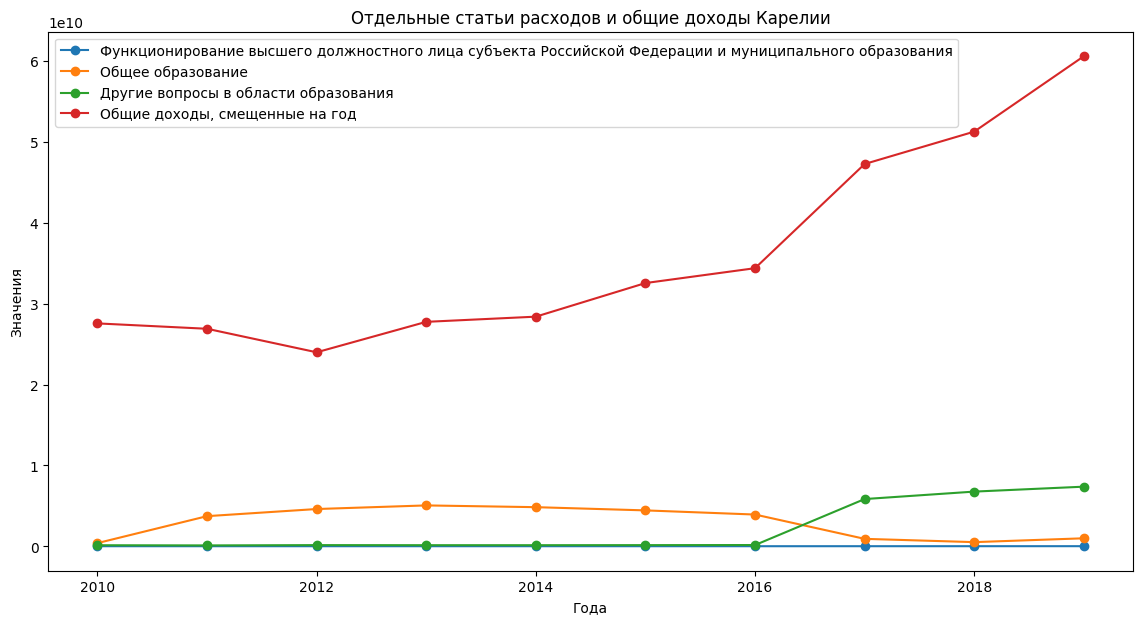

In [ ]:
plt.figure(figsize=(14, 7))

for i in rows_1:
    plt.plot(years, df_exp.iloc[i, 1:11], marker='o', markersize=6, label=f'{df_exp.iloc[i, 0]}')

#plt.plot(years, df_exp.iloc[0, 2:12], marker='o', markersize=6, label="Общие расходы, смещенные на год") график расходов убираем, потому что нам интересна только корреляция/антикорреляция статей расходов с доходами
plt.plot(years, df_inc.iloc[0, 2:12], marker='o', markersize=6, label="Общие доходы, смещенные на год")
plt.title("Отдельные статьи расходов и общие доходы Карелии")
plt.xlabel('Года')
plt.ylabel('Значения')
plt.legend()
plt.show()

## 4. Анализ параметров (2 балла)

На основе графиков и самих параметров, расскажи:

- Построй гипотезы, наблюдаешь ли ты казуацию или здесь просто совпадение?
- Предложи гипотезы, как проверить, нет ли ошибок в твоих выводах
- Проанализируй взаимосвязь с параметрами между собой. Являются ли они сильноскореллированными? Имеет ли смысл использовать их всех вместе или достаточно одного?

In [ ]:
#ищем корреляцию между параметрами доходов
inc_corr_1 = df_inc_corr.iloc[8, 1:11].corr(df_inc_corr.iloc[22, 1:11])
inc_corr_2 = df_inc_corr.iloc[8, 1:11].corr(df_inc_corr.iloc[66, 1:11])
inc_corr_3 = df_inc_corr.iloc[22, 1:11].corr(df_inc_corr.iloc[66, 1:11])
print(inc_corr_1, inc_corr_2, inc_corr_3)
#между параметрами расходов
exp_corr_1 = df_exp_corr.iloc[1, 1:11].corr(df_exp_corr.iloc[21, 1:11])
exp_corr_2 = df_exp_corr.iloc[1, 1:11].corr(df_exp_corr.iloc[24, 1:11])
exp_corr_3 = df_exp_corr.iloc[21, 1:11].corr(df_exp_corr.iloc[24, 1:11])
print(exp_corr_1, exp_corr_2, exp_corr_3)

0.8472921735216722 0.9011040631055344 0.7559908644940219
-0.7218249207757077 0.9497763903491293 -0.7415580053688391



Доходы:
1. Акцизы на пиво, производимое на территории Российской Федерации, сильно коррелируют с доходами Карелии. При этом на графике можем видеть, что их доля в доходах республики очень мала, и они несущественно влияют на величину доходов в целом, поэтому я считаю, что данная взаимосвязь - просто совпадение.
Чтобы это проверить, надо узнать, не связана ли Карелия с пивом каким-то особенным образом.

2. Налог на добычу полезных ископаемых сильно коррелирует с расходами Карелии, при этом он также невелик по сравнению с величиной расходов в следующем году. Поэтому тут можно увидеть совпадение, но.. Все-таки целый еще один параметр, связанный с налогами на природопользование, сильно скоррелирован с расходами Карелии - плата за использование лесов с расходами Карелии. Возможно, Карелия планирует расходы на следующий год исходя из того, сколько налогов на ее территории было собрано, и налоги на природопользование составляют тут значительную часть.
Чтобы это проверить, надо посмотреть, какую часть от всех собранных в Карелии налогов составляют налоги на природопользование, а также как конкретно формируется план расходов на следующий год.

3. БЕЗВОЗМЕЗДНЫЕ ПОСТУПЛЕНИЯ ОТ ДРУГИХ БЮДЖЕТОВ БЮДЖЕТНОЙ СИСТЕМЫ РОССИЙСКОЙ ФЕДЕРАЦИИ сильно коррелируют с доходами Карелии. Возможно, это происходит из-за того, что они составляют весомую часть в доходах Карелии и сильно влияют на ее расходы в целом. Если идет тренд на увеличение безвозмездных поступлений, то Карелия начинает больше тратить не только в текущем, но и в следующем году.
Чтобы каким-то образом оценить верность рассуждений, нужно узнать, насколько существенны безвозмездные поступления для доходов Карелии.


Расходы:
1. Другие вопросы в области образования сильно коррелируют с доходами Карелии. Чем больше Карелия тратит по этой статье в текущем году, тем больше она получает в следующем. Можно подумать, что за счет финансирования образование ВВП Карелии растет и, как следствие, увеличиваются общие налоги и бюджет республики. Но, я думаю, производственная отдача от финансирования образования не может прийти за год, то есть эффект от вклада в образование должен быть более отложенный. Поэтому данная взаимосвязь, по моему мнению, просто совпадение. Чтобы проверить, может ли производственный эффект финансирования образования наступать так быстро, нужно провести анализ данных производственных мощностей республики и отмести(каким-то образом) все остальные возможные причины их изменений.

2. Функционирование высшего должностного лица субъекта Российской Федерации и муниципального образования сильно коррелируют с доходами Карелии. Возможна такая связь: более интенсивная работа главы Карелии увеличивает расходы на его деятельность(не только зар. плата, но и спонсирование командировок, встреч и тд) в текущем году, а также способствует улучшению отношений с другими политическими субъектами, от которых в том числе могут поступать доходы в бюджет Карелии. Для подтверждения этой гипотезы необходимо узнать, насколько существенно зависит доход Карелии от других политических субъектов.

3. Общее образование сильно отрицательно скоррелировано с доходами Карелии. На графике мы видим увеличение расходов на общее образование в 2011-2016 годах, а потом снижение до изначального уровня. Возможно, это обусловлено реформой общего образования или каким-то бюджетным проектом. А тот факт, что снижение расходов на образование предвосхищает увелические доходов и наоборот, может быть просто совпадением.

Среди моих параметров, согласно результатам блока выше, сильно скоррелированными являются пары Акцизы на пиво и Безвозмездные платежи(>0.9) и Функционирование высшего должностного лица и Другие вопросы образования(>0.94). Как мне кажется, между параметрами в этих парах нет связи, и их нужно использовать отдельно.




